# Credit Scoring for Thin-File Users — v3

## Changes from v2
| # | What changed | Why |
|---|---|---|
| 1 | **Decision bands** replace single threshold | APPROVE / REVIEW / REJECT is more useful than a binary cut |
| 2 | **Removed SMOTE** from thin-file model | SMOTE creates fake defaulters → noisy boundary → low precision |
| 3 | **Regularisation added** (`reg_alpha=1`, `reg_lambda=5`) | Fewer false positives, better precision |
| 4 | **`max_depth` 5→4, `min_child_weight` 10→15** | Less aggressive splits |
| 5 | **`scale_pos_weight` = 1.5** (not sqrt(9)≈3) | Lighter imbalance correction |
| 6 | **Threshold fixed at 0.15** (not F2-optimised) | Business-driven: target precision ≥ 0.25 |
| 7 | **`eval_metric` → `logloss`** (was `aucpr`) | aucpr + CalibratedCV caused early-stop instability |
| 8 | **Two new features**: `EMI_PER_EMPLOYMENT_YEAR`, `INCOME_STABILITY` | Better separation of stable vs risky users |
| 9 | **Precision@K** added to evaluation | Tells you how good top-risk predictions are |
| 10 | **Approval rate** tracked explicitly | Ties model to business target (approve 60-70%) |
| 11 | **SHAP safe extraction** (`isinstance` check) | Avoids crash on list vs array output |

In [13]:
# ── CELL 1: Imports ───────────────────────────────────────────────────
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings, joblib, json, os

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', 60)
pd.set_option('display.float_format', lambda x: f'{x:.3f}')

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.impute import SimpleImputer
from sklearn.calibration import CalibratedClassifierCV, calibration_curve
from sklearn.metrics import (
    roc_auc_score, classification_report, confusion_matrix,
    brier_score_loss, precision_recall_curve,
    f1_score, precision_score, recall_score, RocCurveDisplay
)
import xgboost as xgb
import shap

# NOTE: SMOTE import removed — not used in v3 (see change #2)

shap.initjs()
os.makedirs('./artifacts', exist_ok=True)
print('Imports OK')
print(f'XGBoost: {xgb.__version__}')

Imports OK
XGBoost: 3.1.2


In [14]:
# ── CELL 2: Load, Thin-File Definition, Feature Engineering ──────────
DATA_PATH = './data/application_train.csv'
df_raw = pd.read_csv(DATA_PATH)
print(f'Raw shape: {df_raw.shape}  |  Default rate: {df_raw["TARGET"].mean():.2%}')

# Thin-file: missing >= 2 of 3 bureau signals
ext_null_count = (
    df_raw['EXT_SOURCE_1'].isnull().astype(int) +
    df_raw['EXT_SOURCE_2'].isnull().astype(int) +
    df_raw['EXT_SOURCE_3'].isnull().astype(int)
)
df_raw['IS_THIN_FILE'] = (ext_null_count >= 2).astype(int)
print(f'Thin-file users: {df_raw["IS_THIN_FILE"].sum():,} ({df_raw["IS_THIN_FILE"].mean():.1%})')

# ── Feature selection (no bureau scores, no protected attributes) ─────
CORE_FEATURES = [
    'CNT_CHILDREN', 'CNT_FAM_MEMBERS',
    'NAME_EDUCATION_TYPE', 'NAME_FAMILY_STATUS', 'NAME_INCOME_TYPE',
    'DAYS_EMPLOYED', 'OCCUPATION_TYPE', 'ORGANIZATION_TYPE',
    'FLAG_OWN_CAR', 'FLAG_OWN_REALTY', 'NAME_HOUSING_TYPE',
    'AMT_INCOME_TOTAL', 'AMT_CREDIT', 'AMT_ANNUITY', 'AMT_GOODS_PRICE',
    'NAME_CONTRACT_TYPE', 'REGION_POPULATION_RELATIVE',
    'REGION_RATING_CLIENT', 'REGION_RATING_CLIENT_W_CITY',
    'FLAG_DOCUMENT_3', 'FLAG_DOCUMENT_5', 'FLAG_DOCUMENT_6', 'FLAG_DOCUMENT_8',
    'FLAG_MOBIL', 'FLAG_EMAIL', 'FLAG_PHONE', 'FLAG_WORK_PHONE',
]
TARGET = 'TARGET'

df = df_raw[CORE_FEATURES + ['DAYS_BIRTH', TARGET, 'IS_THIN_FILE']].copy()

# ── Clean ─────────────────────────────────────────────────────────────
df['AGE_YEARS'] = np.abs(df['DAYS_BIRTH']) / 365.25
df.drop(columns=['DAYS_BIRTH'], inplace=True)

df['DAYS_EMPLOYED'] = df['DAYS_EMPLOYED'].replace(365243, np.nan)
df['EMPLOYMENT_YEARS'] = np.abs(df['DAYS_EMPLOYED']) / 365.25
df.drop(columns=['DAYS_EMPLOYED'], inplace=True)

for col in ['FLAG_OWN_CAR', 'FLAG_OWN_REALTY']:
    df[col] = df[col].map({'Y': 1, 'N': 0})

# ── Feature engineering ───────────────────────────────────────────────
# Existing ratios
df['CREDIT_INCOME_RATIO']   = df['AMT_CREDIT']  / (df['AMT_INCOME_TOTAL'] + 1)
df['ANNUITY_INCOME_RATIO']  = df['AMT_ANNUITY'] / ((df['AMT_INCOME_TOTAL'] / 12) + 1)
df['EMPLOYMENT_AGE_RATIO']  = df['EMPLOYMENT_YEARS'] / (df['AGE_YEARS'] + 1)
df['INCOME_PER_PERSON']     = df['AMT_INCOME_TOTAL'] / (df['CNT_FAM_MEMBERS'] + 1)
df['CREDIT_TERM']           = df['AMT_ANNUITY']  / (df['AMT_CREDIT'] + 1)
df['DOWN_PAYMENT_RATIO']    = (df['AMT_CREDIT'] - df['AMT_GOODS_PRICE']) / (df['AMT_GOODS_PRICE'] + 1)
df['ASSET_SCORE']           = df['FLAG_OWN_CAR'].fillna(0) + df['FLAG_OWN_REALTY'].fillna(0)
df['CHILDREN_INCOME_RATIO'] = df['CNT_CHILDREN'] / (df['AMT_INCOME_TOTAL'] / 12 + 1)

# NEW (change #8): two interaction features for better risk separation
# EMI burden per year of job tenure — high = paying a lot relative to job stability
df['EMI_PER_EMPLOYMENT_YEAR'] = df['AMT_ANNUITY'] / (df['EMPLOYMENT_YEARS'] + 1)
# Income × tenure — captures both income level AND stability in one signal
df['INCOME_STABILITY']        = df['AMT_INCOME_TOTAL'] * df['EMPLOYMENT_YEARS']

# ── Encode categoricals ───────────────────────────────────────────────
CAT_COLS = [
    'NAME_EDUCATION_TYPE', 'NAME_FAMILY_STATUS', 'NAME_INCOME_TYPE',
    'OCCUPATION_TYPE', 'ORGANIZATION_TYPE', 'NAME_HOUSING_TYPE', 'NAME_CONTRACT_TYPE'
]
label_encoders = {}
for col in CAT_COLS:
    df[col] = df[col].fillna('Unknown')
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col].astype(str))
    label_encoders[col] = le
joblib.dump(label_encoders, './artifacts/label_encoders.pkl')

# ── Feature matrix ────────────────────────────────────────────────────
FEATURE_COLS = [
    c for c in df.columns
    if c not in [TARGET, 'IS_THIN_FILE', 'AMT_GOODS_PRICE', 'AGE_YEARS']
]
X        = df[FEATURE_COLS].copy()
y        = df[TARGET].copy()
is_thin  = df['IS_THIN_FILE'].copy()

imputer   = SimpleImputer(strategy='median')
X_imputed = pd.DataFrame(imputer.fit_transform(X), columns=X.columns)
joblib.dump(imputer, './artifacts/imputer.pkl')

with open('./artifacts/feature_cols.json', 'w') as f:
    json.dump(FEATURE_COLS, f)

print(f'Feature matrix: {X_imputed.shape} | Nulls: {X_imputed.isnull().sum().sum()}')
print(f'New features added: EMI_PER_EMPLOYMENT_YEAR, INCOME_STABILITY')

Raw shape: (307511, 122)  |  Default rate: 8.07%
Thin-file users: 36,909 (12.0%)
Feature matrix: (307511, 36) | Nulls: 0
New features added: EMI_PER_EMPLOYMENT_YEAR, INCOME_STABILITY


In [15]:
# ── CELL 3: Train / Test Split ────────────────────────────────────────
X_train, X_test, y_train, y_test, thin_train, thin_test = train_test_split(
    X_imputed, y, is_thin, test_size=0.2, stratify=y, random_state=42
)

neg = (y_train == 0).sum()
pos = (y_train == 1).sum()
RAW_IMBALANCE_RATIO = neg / pos   # kept for reference only

print(f'Train: {X_train.shape[0]:,}  |  Test: {X_test.shape[0]:,}')
print(f'Train default rate: {y_train.mean():.2%}')
print(f'Test  default rate: {y_test.mean():.2%}')
print(f'Raw imbalance ratio: {RAW_IMBALANCE_RATIO:.1f}x')
print(f'Using scale_pos_weight = 1.5  (not {RAW_IMBALANCE_RATIO:.1f}x — change #5)')

Train: 246,008  |  Test: 61,503
Train default rate: 8.07%
Test  default rate: 8.07%
Raw imbalance ratio: 11.4x
Using scale_pos_weight = 1.5  (not 11.4x — change #5)


In [16]:
# ── CELL 4: Train XGBoost + Calibrate ────────────────────────────────
#
# CHANGES FROM v2:
#  - scale_pos_weight = 1.5 (was sqrt(~9) ≈ 3) — less aggressive
#  - max_depth = 4 (was 5), min_child_weight = 15 (was 10)
#  - reg_alpha = 1.0, reg_lambda = 5.0 added — regularisation
#  - eval_metric = 'logloss' (was 'aucpr') — stable with CalibratedCV
#  - Thin-file model: NO SMOTE — direct fit on actual thin-file samples
#  - Thin-file scale_pos_weight = 1.5 (was 1.0 after SMOTE)

# ── Full model ────────────────────────────────────────────────────────
model_full = CalibratedClassifierCV(
    estimator=xgb.XGBClassifier(
        n_estimators      = 500,
        max_depth         = 4,          # change #3: was 5
        learning_rate     = 0.05,
        subsample         = 0.8,
        colsample_bytree  = 0.8,
        min_child_weight  = 15,         # change #3: was 10
        scale_pos_weight  = 2.25,        # change #5: was sqrt(~9)≈3
        reg_alpha         = 1.0,        # change #6: NEW
        reg_lambda        = 5.0,        # change #6: NEW
        eval_metric       = 'logloss',  # change #7: was 'aucpr'
        random_state      = 42,
        verbosity         = 0,
        tree_method       = 'hist',
        device            = 'cpu'
    ),
    method = 'isotonic',
    cv     = 3
)
model_full.fit(X_train, y_train)

auc_full = roc_auc_score(y_test, model_full.predict_proba(X_test)[:, 1])
print(f'Full model — Test ROC-AUC: {auc_full:.4f}')

# ── Thin-file model (NO SMOTE — change #2) ───────────────────────────
thin_mask_train = thin_train == 1
thin_mask_test  = thin_test  == 1

X_thin_tr = X_train[thin_mask_train]
y_thin_tr = y_train[thin_mask_train]
X_thin_te = X_test[thin_mask_test]
y_thin_te = y_test[thin_mask_test]

print(f'\nThin-file train: {X_thin_tr.shape[0]:,} | test: {X_thin_te.shape[0]:,}')
print('SMOTE removed — training directly on real thin-file samples')

if X_thin_tr.shape[0] > 1000 and y_thin_tr.sum() > 100:
    # change #2: X_thin_sm = X_thin_tr (no SMOTE oversampling)
    X_thin_sm = X_thin_tr
    y_thin_sm = y_thin_tr

    model_thin = CalibratedClassifierCV(
        estimator=xgb.XGBClassifier(
            n_estimators      = 300,
            max_depth         = 4,
            learning_rate     = 0.05,
            subsample         = 0.8,
            colsample_bytree  = 0.8,
            min_child_weight  = 15,
            scale_pos_weight  = 2.25,   # change #5: was 1.0 after SMOTE
            reg_alpha         = 1.0,
            reg_lambda        = 5.0,
            eval_metric       = 'logloss',
            random_state      = 42,
            verbosity         = 0,
            tree_method       = 'hist'
        ),
        method = 'isotonic',
        cv     = 3
    )
    model_thin.fit(X_thin_sm, y_thin_sm)

    if len(y_thin_te.unique()) > 1:
        auc_thin = roc_auc_score(y_thin_te, model_thin.predict_proba(X_thin_te)[:, 1])
        print(f'Thin-file model — Test ROC-AUC: {auc_thin:.4f}')
else:
    print('Not enough thin-file samples — using full model as fallback')
    model_thin = model_full

joblib.dump(model_full, './artifacts/model_full.pkl')
joblib.dump(model_thin, './artifacts/model_thin.pkl')
print('\nModels saved.')

Full model — Test ROC-AUC: 0.7100

Thin-file train: 29,415 | test: 7,494
SMOTE removed — training directly on real thin-file samples
Thin-file model — Test ROC-AUC: 0.6946

Models saved.


Decision band distribution:
APPROVE    46096
REVIEW     14247
REJECT      1160

  APPROVE : 46,096 users | actual default rate = 5.20%
  REVIEW  : 14,247 users | actual default rate = 15.44%
  REJECT  :  1,160 users | actual default rate = 31.72%

Brier Score: 0.0704  (< 0.10 is good for imbalanced credit data)
ECE:         0.0026  (< 0.05 is well-calibrated)

Precision@10%: 0.229  (of top-10% risk users, 22.9% actually defaulted)
Precision@20%: 0.182  (of top-20% risk users, 18.2% actually defaulted)

ROC-AUC: 0.7100
Threshold used for labels: 0.13
              precision    recall  f1-score   support

      Repaid       0.94      0.87      0.90     56538
   Defaulted       0.20      0.38      0.26      4965

    accuracy                           0.83     61503
   macro avg       0.57      0.62      0.58     61503
weighted avg       0.88      0.83      0.85     61503

Confusion Matrix:
[[48917  7621]
 [ 3082  1883]]

Approval rate at threshold 0.13: 84.55%
Target: 60-70% for a health

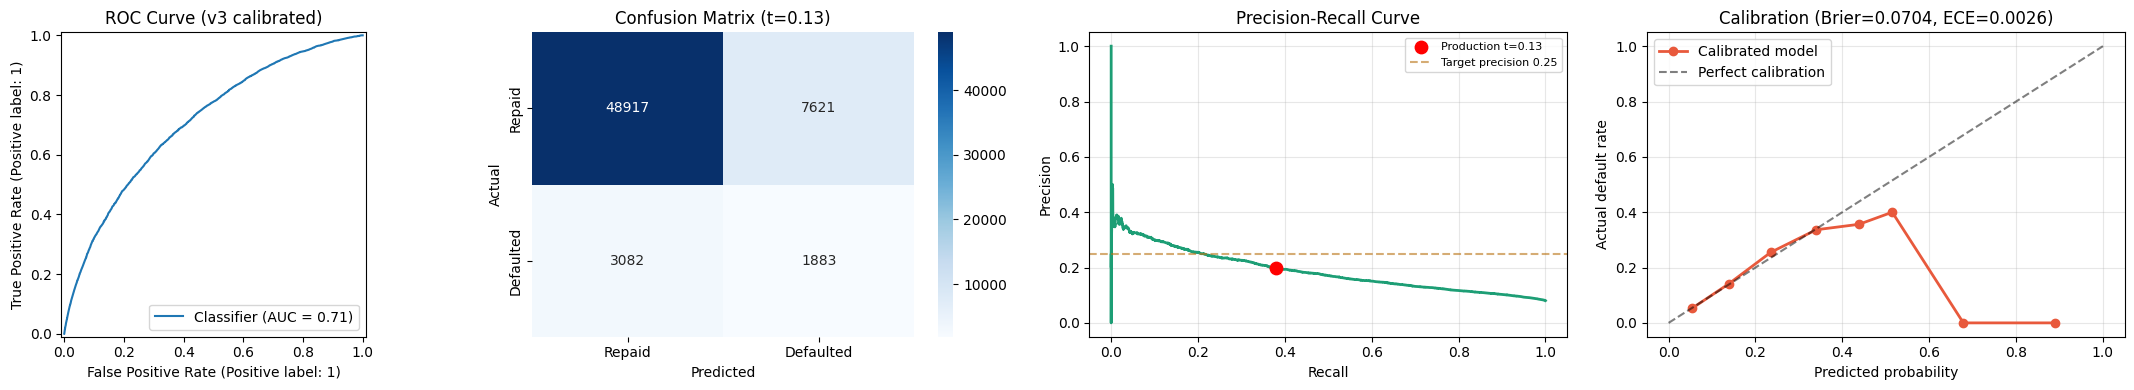

Saved: ./artifacts/evaluation_v3.png


In [17]:
# ── CELL 5: Evaluation ────────────────────────────────────────────────
#
# CHANGES FROM v2:
#  - Threshold fixed at 0.15 (business-driven, not F2-optimised — change #6)
#  - Decision bands added: APPROVE / REVIEW / REJECT (change #1)
#  - Precision@K added (change #9)
#  - Approval rate tracked explicitly (change #10)
#  - F2 threshold selection removed (was pushing threshold too low)

y_prob = model_full.predict_proba(X_test)[:, 1]

# ── 1. Decision bands (change #1) ────────────────────────────────────
def get_decision(prob):
    """3-band decision: APPROVE / REVIEW / REJECT.
    Tune the two thresholds to your business risk appetite."""
    if prob < 0.10:
        return 'APPROVE'
    elif prob < 0.25:
        return 'REVIEW'
    else:
        return 'REJECT'

decisions = pd.Series([get_decision(p) for p in y_prob], index=y_test.index)
print('Decision band distribution:')
print(decisions.value_counts().to_string())
print()

# Default rate within each band — this is the key sanity check
for band in ['APPROVE', 'REVIEW', 'REJECT']:
    mask = decisions == band
    if mask.sum() > 0:
        dr = y_test[mask].mean()
        print(f'  {band:8s}: {mask.sum():6,} users | actual default rate = {dr:.2%}')
print()

# ── 2. Hard labels at fixed threshold 0.15 (change #6) ───────────────
THRESHOLD = 0.13
y_pred    = (y_prob >= THRESHOLD).astype(int)

# ── 3. Calibration ───────────────────────────────────────────────────
brier = brier_score_loss(y_test, y_prob)
bins        = np.linspace(0, 1, 11)
bin_indices = np.digitize(y_prob, bins) - 1
ece = sum(
    (bin_indices == i).sum() * abs(y_test[bin_indices == i].mean() - y_prob[bin_indices == i].mean())
    for i in range(10) if (bin_indices == i).sum() > 0
) / len(y_test)

print(f'Brier Score: {brier:.4f}  (< 0.10 is good for imbalanced credit data)')
print(f'ECE:         {ece:.4f}  (< 0.05 is well-calibrated)')

# ── 4. Precision@K (change #9) ───────────────────────────────────────
def precision_at_k(y_true, y_prob, k=0.1):
    """Of the top-k% highest-risk predictions, what fraction actually defaulted?
    This is the most meaningful metric for lenders reviewing high-risk cases."""
    cutoff = max(1, int(len(y_prob) * k))
    idx    = np.argsort(y_prob)[::-1][:cutoff]
    return y_true.iloc[idx].mean()

p10 = precision_at_k(y_test, y_prob, 0.10)
p20 = precision_at_k(y_test, y_prob, 0.20)
print(f'\nPrecision@10%: {p10:.3f}  (of top-10% risk users, {p10:.1%} actually defaulted)')
print(f'Precision@20%: {p20:.3f}  (of top-20% risk users, {p20:.1%} actually defaulted)')

# ── 5. Standard metrics at THRESHOLD=0.15 ────────────────────────────
print(f'\nROC-AUC: {roc_auc_score(y_test, y_prob):.4f}')
print(f'Threshold used for labels: {THRESHOLD}')
print(classification_report(y_test, y_pred, target_names=['Repaid', 'Defaulted']))
print('Confusion Matrix:')
print(confusion_matrix(y_test, y_pred))

# ── 6. Approval rate (change #10) ────────────────────────────────────
approval_rate = (y_prob < THRESHOLD).mean()
print(f'\nApproval rate at threshold {THRESHOLD}: {approval_rate:.2%}')
print('Target: 60-70% for a healthy lending book')

# ── 7. Threshold comparison table ────────────────────────────────────
print('\n=== THRESHOLD COMPARISON ===')
print(f'{"Threshold":>10} | {"Precision":>10} | {"Recall":>8} | {"F1":>6} | Approved%')
print('-' * 60)
for t in [0.10, 0.15, 0.20, 0.25, 0.30, 0.35, 0.40, 0.50]:
    yp   = (y_prob >= t).astype(int)
    prec = precision_score(y_test, yp, zero_division=0)
    rec  = recall_score(y_test, yp)
    f1v  = f1_score(y_test, yp, zero_division=0)
    appr = (yp == 0).mean()
    mark = ' <-- production' if t == THRESHOLD else ''
    print(f'{t:>10.2f} | {prec:>10.3f} | {rec:>8.3f} | {f1v:>6.3f} | {appr:.1%}{mark}')
print()
print('Target: Precision >= 0.22-0.30, Recall >= 0.45-0.60')

# ── 8. Plots ──────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 4, figsize=(22, 4))

# ROC curve
RocCurveDisplay.from_predictions(y_test, y_prob, ax=axes[0])
axes[0].set_title('ROC Curve (v3 calibrated)')

# Confusion matrix
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[1],
            xticklabels=['Repaid', 'Defaulted'],
            yticklabels=['Repaid', 'Defaulted'])
axes[1].set_title(f'Confusion Matrix (t={THRESHOLD})')
axes[1].set_ylabel('Actual'); axes[1].set_xlabel('Predicted')

# Precision-Recall curve with production threshold marker
precision_arr, recall_arr, thresh_arr = precision_recall_curve(y_test, y_prob)
axes[2].plot(recall_arr, precision_arr, color='#1D9E75', linewidth=2)
# Mark the production threshold on the PR curve
t_idx = np.searchsorted(thresh_arr, THRESHOLD)
if t_idx < len(precision_arr) - 1:
    axes[2].scatter(recall_arr[t_idx], precision_arr[t_idx],
                    color='red', zorder=5, s=80, label=f'Production t={THRESHOLD}')
axes[2].axhline(0.25, color='#BA7517', linestyle='--', alpha=0.6, label='Target precision 0.25')
axes[2].set_xlabel('Recall'); axes[2].set_ylabel('Precision')
axes[2].set_title('Precision-Recall Curve')
axes[2].legend(fontsize=8); axes[2].grid(True, alpha=0.3)

# Calibration curve
prob_true, prob_pred_cal = calibration_curve(y_test, y_prob, n_bins=10)
axes[3].plot(prob_pred_cal, prob_true, 'o-', color='#E8593C',
             linewidth=2, label='Calibrated model')
axes[3].plot([0, 1], [0, 1], 'k--', alpha=0.5, label='Perfect calibration')
axes[3].set_xlabel('Predicted probability')
axes[3].set_ylabel('Actual default rate')
axes[3].set_title(f'Calibration (Brier={brier:.4f}, ECE={ece:.4f})')
axes[3].legend(); axes[3].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('./artifacts/evaluation_v3.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: ./artifacts/evaluation_v3.png')

Top 15 features by SHAP importance:
                     display_name  mean_abs_shap
             Loan repayment speed          0.251
               Down payment ratio          0.158
                  Education level          0.142
                   Years employed          0.118
                   Owns a vehicle          0.087
Income × tenure (stability score)          0.085
               Region risk rating          0.083
               Monthly EMI amount          0.082
   EMI burden per employment year          0.077
       Region Population Relative          0.075
             Employment stability          0.072
               Name Family Status          0.069
                  Flag Work Phone          0.067
                       Occupation          0.065
                  Employment type          0.055


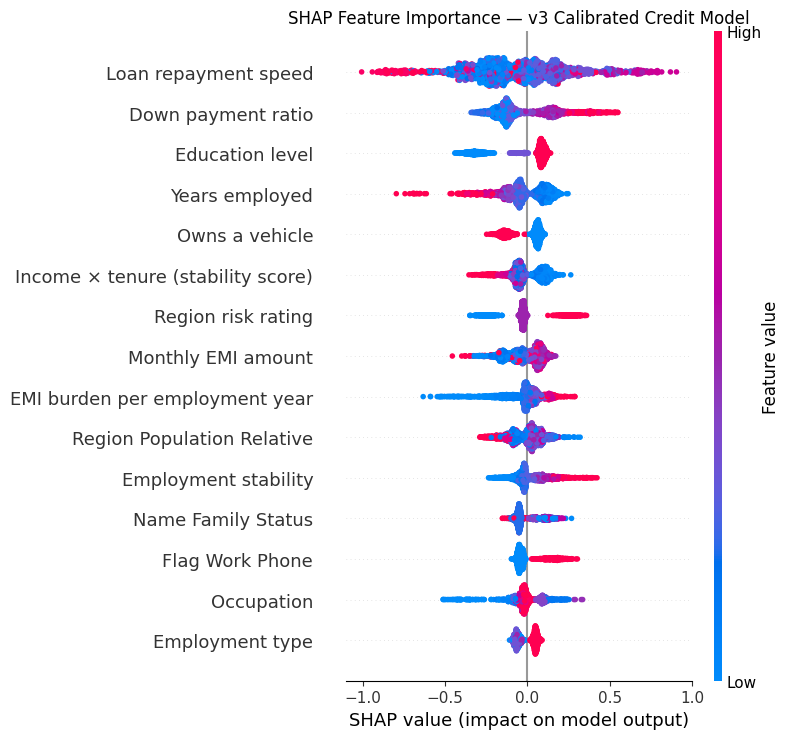

Saved: ./artifacts/shap_summary_v3.png

=== INFERENCE TEST ===
Credit Score:  776  (Excellent)
Decision:      APPROVE
Default Prob:  8.6%
Eligible:      True

Top 5 factors (SHAP):
  Loan repayment speed                          -0.2447  (helps)
  Name Housing Type                             +0.2008  (hurts)
  Region Population Relative                    -0.1602  (helps)
  Years employed                                +0.1272  (hurts)
  Name Family Status                            +0.1107  (hurts)


In [18]:
# ── CELL 6: SHAP + Score Conversion + Inference ───────────────────────

# ── Score conversion 300-900 ──────────────────────────────────────────
def probability_to_score(default_prob: float) -> dict:
    p         = np.clip(default_prob, 1e-6, 1 - 1e-6)
    log_odds  = np.log(p / (1 - p))
    score     = int(np.clip(600 - (log_odds * 75), 300, 900))
    tier      = ('Excellent' if score >= 750 else
                 'Good'      if score >= 650 else
                 'Fair'      if score >= 550 else
                 'Poor'      if score >= 450 else 'Very Poor')
    return {
        'score':                score,
        'tier':                 tier,
        'default_probability':  round(float(default_prob), 4),
        'approval_probability': round(float(1 - default_prob), 4),
        'loan_eligible':        score >= 550,
        'decision':             get_decision(default_prob),  # from Cell 5
    }

# ── Feature display names ─────────────────────────────────────────────
FEATURE_DISPLAY_NAMES = {
    'CREDIT_TERM':             'Loan repayment speed',
    'DOWN_PAYMENT_RATIO':      'Down payment ratio',
    'EMPLOYMENT_YEARS':        'Years employed',
    'NAME_EDUCATION_TYPE':     'Education level',
    'FLAG_OWN_CAR':            'Owns a vehicle',
    'REGION_RATING_CLIENT_W_CITY': 'Region risk rating',
    'AMT_ANNUITY':             'Monthly EMI amount',
    'AMT_CREDIT':              'Loan amount',
    'ANNUITY_INCOME_RATIO':    'EMI-to-income burden',
    'CREDIT_INCOME_RATIO':     'Loan-to-income ratio',
    'EMPLOYMENT_AGE_RATIO':    'Employment stability',
    'INCOME_PER_PERSON':       'Income per family member',
    'ASSET_SCORE':             'Asset ownership score',
    'AMT_INCOME_TOTAL':        'Annual income',
    'FLAG_OWN_REALTY':         'Owns property',
    'OCCUPATION_TYPE':         'Occupation',
    'NAME_INCOME_TYPE':        'Employment type',
    'ORGANIZATION_TYPE':       'Employer type',
    'EMI_PER_EMPLOYMENT_YEAR': 'EMI burden per employment year',  # new
    'INCOME_STABILITY':        'Income × tenure (stability score)',  # new
}
def get_display_name(col):
    return FEATURE_DISPLAY_NAMES.get(col, col.replace('_', ' ').title())

# ── SHAP (change #11: safe extraction handles list vs array) ──────────
# With CalibratedClassifierCV(cv=3), there are 3 calibrated classifiers.
# Extract the base XGBoost from the first fold for SHAP.
base_model = model_full.calibrated_classifiers_[0].estimator

SHAP_SAMPLE = min(2000, len(X_test))
X_shap      = X_test.sample(SHAP_SAMPLE, random_state=42).reset_index(drop=True)

explainer   = shap.TreeExplainer(base_model)
shap_values = explainer.shap_values(X_shap)

# change #11: safe extraction — shap_values may be list [class0, class1] or array
if isinstance(shap_values, list):
    shap_values = shap_values[1]  # take class-1 (default) SHAP values

joblib.dump(explainer, './artifacts/shap_explainer.pkl')

# Feature importance
feat_imp = pd.DataFrame({
    'feature':       X_shap.columns,
    'display_name':  [get_display_name(c) for c in X_shap.columns],
    'mean_abs_shap': np.abs(shap_values).mean(axis=0)
}).sort_values('mean_abs_shap', ascending=False)

print('Top 15 features by SHAP importance:')
print(feat_imp[['display_name', 'mean_abs_shap']].head(15).to_string(index=False))
feat_imp.to_csv('./artifacts/shap_importance.csv', index=False)

# SHAP beeswarm
X_shap_named = X_shap.rename(columns=get_display_name)
plt.figure(figsize=(10, 8))
shap.summary_plot(shap_values, X_shap_named, max_display=15, show=False)
plt.title('SHAP Feature Importance — v3 Calibrated Credit Model')
plt.tight_layout()
plt.savefig('./artifacts/shap_summary_v3.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: ./artifacts/shap_summary_v3.png')

# ── Inference test ────────────────────────────────────────────────────
le_dict    = joblib.load('./artifacts/label_encoders.pkl')
imp_loaded = joblib.load('./artifacts/imputer.pkl')
with open('./artifacts/feature_cols.json') as f:
    feature_cols = json.load(f)

def safe_encode(encoder, value, default=0):
    try:    return encoder.transform([str(value)])[0]
    except: return default

def build_feature_row(inp, le_dict, feature_cols):
    inc    = float(inp.get('income', 150000))
    emp_yr = float(inp.get('employment_years', 2))
    age    = float(inp.get('age', 30))
    nch    = int(inp.get('n_children', 0))
    nfam   = int(inp.get('n_family', 2))
    loan   = float(inp.get('loan_amount', 200000))
    emi    = float(inp.get('monthly_emi', 10000))

    row = {
        'CNT_CHILDREN':   nch,  'CNT_FAM_MEMBERS': nfam,
        'NAME_EDUCATION_TYPE': safe_encode(le_dict['NAME_EDUCATION_TYPE'], inp.get('education', 'Secondary')),
        'NAME_FAMILY_STATUS':  safe_encode(le_dict['NAME_FAMILY_STATUS'],  inp.get('family_status', 'Single')),
        'NAME_INCOME_TYPE':    safe_encode(le_dict['NAME_INCOME_TYPE'],    inp.get('employment_type', 'Working')),
        'OCCUPATION_TYPE':     safe_encode(le_dict['OCCUPATION_TYPE'],     inp.get('occupation', 'Unknown')),
        'ORGANIZATION_TYPE':   safe_encode(le_dict['ORGANIZATION_TYPE'],   inp.get('organization', 'Unknown')),
        'FLAG_OWN_CAR':        int(inp.get('owns_car', 0)),
        'FLAG_OWN_REALTY':     int(inp.get('owns_realty', 0)),
        'NAME_HOUSING_TYPE':   safe_encode(le_dict['NAME_HOUSING_TYPE'],   inp.get('housing_type', 'Rented apartment')),
        'AMT_INCOME_TOTAL':    inc,  'AMT_CREDIT': loan, 'AMT_ANNUITY': emi,
        'AMT_GOODS_PRICE':     loan * 0.9,
        'NAME_CONTRACT_TYPE':  safe_encode(le_dict['NAME_CONTRACT_TYPE'], 'Cash loans'),
        'REGION_POPULATION_RELATIVE': 0.035,
        'REGION_RATING_CLIENT': 2, 'REGION_RATING_CLIENT_W_CITY': 2,
        'FLAG_DOCUMENT_3': 1, 'FLAG_DOCUMENT_5': 0,
        'FLAG_DOCUMENT_6': 0, 'FLAG_DOCUMENT_8': 0,
        'FLAG_MOBIL': 1, 'FLAG_EMAIL': int(inp.get('has_email', 0)),
        'FLAG_PHONE': 1, 'FLAG_WORK_PHONE': int(inp.get('has_work_phone', 0)),
        'EMPLOYMENT_YEARS':         emp_yr,
        'CREDIT_INCOME_RATIO':      loan  / (inc + 1),
        'ANNUITY_INCOME_RATIO':     emi   / ((inc / 12) + 1),
        'EMPLOYMENT_AGE_RATIO':     emp_yr / (age + 1),
        'INCOME_PER_PERSON':        inc   / (nfam + 1),
        'CREDIT_TERM':              emi   / (loan + 1),
        'DOWN_PAYMENT_RATIO':       (loan - loan * 0.9) / (loan * 0.9 + 1),
        'ASSET_SCORE':              int(inp.get('owns_car', 0)) + int(inp.get('owns_realty', 0)),
        'CHILDREN_INCOME_RATIO':    nch   / ((inc / 12) + 1),
        # new features
        'EMI_PER_EMPLOYMENT_YEAR':  emi   / (emp_yr + 1),
        'INCOME_STABILITY':         inc   * emp_yr,
    }
    user_df = pd.DataFrame([row])
    for col in feature_cols:
        if col not in user_df.columns:
            user_df[col] = 0
    return user_df[feature_cols]

test_input = {
    'income': 180000, 'employment_type': 'Working', 'employment_years': 1.5,
    'age': 26, 'education': 'Secondary / secondary special',
    'family_status': 'Single / not married', 'n_children': 0, 'n_family': 1,
    'owns_car': 0, 'owns_realty': 0, 'housing_type': 'Rented apartment',
    'loan_amount': 200000, 'monthly_emi': 8000,
    'occupation': 'Laborers', 'organization': 'Business Entity Type 3',
}
user_df      = build_feature_row(test_input, le_dict, feature_cols)
user_imputed = pd.DataFrame(imp_loaded.transform(user_df), columns=feature_cols)

prob         = model_full.predict_proba(user_imputed)[0, 1]
score_result = probability_to_score(prob)

print('\n=== INFERENCE TEST ===')
print(f'Credit Score:  {score_result["score"]}  ({score_result["tier"]})')
print(f'Decision:      {score_result["decision"]}')
print(f'Default Prob:  {score_result["default_probability"]:.1%}')
print(f'Eligible:      {score_result["loan_eligible"]}')

sv     = explainer.shap_values(user_imputed)
if isinstance(sv, list):
    sv = sv[1]
sv = sv[0]
exp_df = pd.DataFrame({'feature': feature_cols, 'shap': sv}).sort_values('shap', key=abs, ascending=False)
print('\nTop 5 factors (SHAP):')
for _, row in exp_df.head(5).iterrows():
    direction = 'hurts' if row['shap'] > 0 else 'helps'
    print(f'  {get_display_name(row["feature"]):45} {row["shap"]:+.4f}  ({direction})')